# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

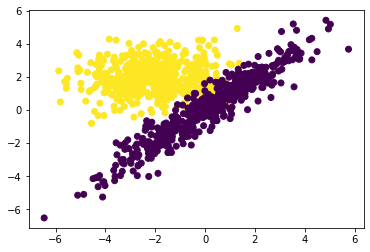

In [3]:
synth= syn.synthetic_data_generator(n=500,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [4]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

#x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [5]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.560872,1.351451,0.715337,1.897247
1,-1.383650,2.152384,2.335504,3.326608
2,-0.572045,1.780188,-3.988716,-3.308463
3,-0.887870,1.454725,1.830560,-2.859227
4,-1.312705,1.363046,-2.877647,3.190917


# ML model setup

In [6]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [7]:
# Creates and train ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')

xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


0.95

In [8]:
# Creates and train ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.95

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


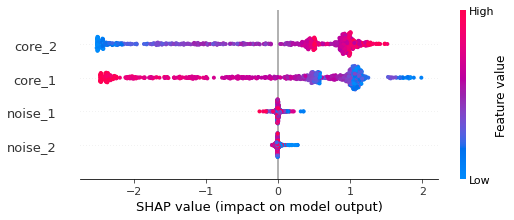

In [9]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [10]:
shap_values[1]

.values =
array([ 1.0195308 ,  1.0111632 , -0.0055641 , -0.00555128], dtype=float32)

.base_values =
-0.019608695

.data =
array([-1.95358622,  2.69187525, -1.22292055, -1.60805497])

In [11]:
sh_vals= pd.DataFrame(shap_values[1].values, train.columns).T

sh_vals

,core_1,core_2,noise_1,noise_2
0,1.019531,1.011163,-0.005564,-0.005551


In [12]:
train.head()

,core_1,core_2,noise_1,noise_2
281,-0.878378,1.006155,-1.744662,-2.926934
42,-1.953586,2.691875,-1.222921,-1.608055
255,-4.378685,2.110515,-1.159593,-3.521924
906,-2.913937,-2.633490,3.837338,-1.567798
394,-2.611191,2.446543,-0.234077,1.978514


In [13]:
labels_train.head()

,target
281,1.0
42,1.0
255,1.0
906,0.0
394,1.0


# FAR test - Global version with no retraining

In [14]:
num_fts= len(x_syn.columns)

replace_ft= far.replace_values(x_syn, x_syn.columns, num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, test, labels_test, verbose=True)

--- 0.16 seconds ---


In [15]:
acc_all_fts= xgb_acc

# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [16]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.486570
core_1     0.481335
noise_1    0.021517
noise_2    0.010578
dtype: float64

In [17]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.376307
core_1     0.224739
noise_2    0.200348
noise_1    0.198606
dtype: float64

In [18]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.375654
core_1     0.224869
noise_2    0.200174
noise_1    0.199303
dtype: float64

In [19]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.492947
core_1     0.490275
noise_1    0.011240
noise_2    0.005539
dtype: float64

# FAR test - PageRank Global version with no retraining

In [20]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= far.p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.p_matrix_to_row_stochastic_matrix(p_matrix4)

In [21]:
# using networkx lib

In [22]:
far.run_lib_pr(st_matrix1, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.486570
core_1     0.481335
noise_1    0.021517
noise_2    0.010578
dtype: float64

In [23]:
far.run_lib_pr(st_matrix2, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.376307
core_1     0.224739
noise_2    0.200348
noise_1    0.198606
dtype: float64

In [24]:
far.run_lib_pr(st_matrix3, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.375654
core_1     0.224869
noise_2    0.200174
noise_1    0.199303
dtype: float64

In [25]:
far.run_lib_pr(st_matrix4, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.492947
core_1     0.490275
noise_1    0.011240
noise_2    0.005539
dtype: float64

In [26]:
# using my PageRank lib

In [27]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.553531
core_2     0.298934
noise_1    0.075261
noise_2    0.072273
dtype: float64

In [28]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_2     0.384895
core_1     0.350150
noise_2    0.132800
noise_1    0.132155
dtype: float64

In [29]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_2     0.384643
core_1     0.350153
noise_2    0.132763
noise_1    0.132441
dtype: float64

In [30]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.557865
core_2     0.297899
noise_1    0.072888
noise_2    0.071348
dtype: float64

# FAR test - Local version - data and target

In [31]:
# the instance to be explained (from train dataset)
target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

# FAR test - Local version with no retraining

In [79]:
num_fts= len(x_syn.columns)

replace_ft_zero= replace_ft.copy()
replace_ft_zero[x_syn.columns]= 0

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft_zero, target_inst, target_labl, verbose=True)

--- 0.13 seconds ---


In [80]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [81]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [82]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [83]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.442308
core_1     0.442308
noise_2    0.057692
noise_1    0.057692
dtype: float64

In [84]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.442308
core_1     0.442308
noise_2    0.057692
noise_1    0.057692
dtype: float64

# FAR test - Knn-only local version

In [38]:
# neighborhood with similar elements, i.e., only instances from the same class of target instance

neigh_lb_test= labels_test[labels_test.target== target_labl.iloc[0,0]]

neigh_ft_test= test.loc[neigh_lb_test.index]

In [39]:
acc_no_i, acc_no_ij= far.knn_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test, 
                                                     target_inst, target_labl, neighb_size= 0.3, verbose=True)

--- 0.08 seconds ---


In [40]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [41]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [42]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [43]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.304348
core_2     0.304348
noise_1    0.195652
noise_2    0.195652
dtype: float64

In [44]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.304348
core_2     0.304348
noise_1    0.195652
noise_2    0.195652
dtype: float64

# FAR test - KnnFold local version

In [45]:
acc_no_i, acc_no_ij= far.knnfold_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test,
                                                         target_inst, target_labl, neighb_size= 0.5, k_folds=10,
                                                         verbose=True)

--- 0.75 seconds ---


In [46]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [47]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [48]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    1.110223e-16
noise_2    1.110223e-16
dtype: float64

In [49]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.339424
core_2     0.339424
noise_2    0.160576
noise_1    0.160576
dtype: float64

In [50]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.339424
core_2     0.339424
noise_2    0.160576
noise_1    0.160576
dtype: float64

# FAR test - KnnFold local version PageRank

In [51]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [52]:
# using networkx lib

In [53]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_1     0.434782
core_2     0.434782
noise_1    0.065218
noise_2    0.065218
dtype: float64

In [54]:
far.run_lib_pr(st_matrix2, x_syn.columns)

core_1     0.434782
core_2     0.434782
noise_1    0.065218
noise_2    0.065218
dtype: float64

In [55]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_1     0.325803
core_2     0.325803
noise_1    0.174197
noise_2    0.174197
dtype: float64

In [56]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_1     0.325803
core_2     0.325803
noise_1    0.174197
noise_2    0.174197
dtype: float64

In [57]:
# using my PageRank lib

In [58]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.559972
core_2     0.235338
noise_1    0.102345
noise_2    0.102345
dtype: float64

In [59]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.559972
core_2     0.235338
noise_1    0.102345
noise_2    0.102345
dtype: float64

In [60]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.459789
core_2     0.273020
noise_1    0.153918
noise_2    0.113273
dtype: float64

In [61]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.459789
core_2     0.273020
noise_1    0.153918
noise_2    0.113273
dtype: float64

# FAR test - Global version with retraining

In [62]:
repeat_train= 5

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

acc_no_i, acc_no_ij= far.remove_and_retrain(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train,verbose=True)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


--- 35.15 seconds ---


In [63]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [64]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.474333
core_1     0.458786
noise_1    0.038013
noise_2    0.028869
dtype: float64

In [65]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.333206
noise_1    0.236056
noise_2    0.226028
core_1     0.204709
dtype: float64

In [66]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.332884
noise_1    0.235952
noise_2    0.226223
core_1     0.204941
dtype: float64

In [67]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.486015
core_1     0.477494
noise_1    0.020699
noise_2    0.015792
dtype: float64